# **Matplotlib Practice**
ref: [matplotlib for Data Visualization](https://www.analyticsvidhya.com/blog/2020/02/beginner-guide-matplotlib-data-visualization-exploration-python/)
### **Food Demand Dataset**

The data set is related to a meal delivery company which operates in multiple cities. They have various fulfilment centers in these cities for dispatching meal orders to their customers.

The dataset consists of historical data of demand for a product-center combination for weeks 1 to 145.

- id: Unique ID
- week: Week No
- center_id: Unique ID for fulfillment center
- meal_id: Unique ID for Meal
- checkout_price: Final price including discount, taxes & delivery charges
- base_price: Base price of the meal
- emailer_for_promotion: Emailer sent for promotion of meal
- homepage_featured: Meal featured at homepage
- num_orders: Orders Count
- city_code: Unique code for city
- region_code: Unique code for region
- center_type: Anonymized center type
- op_area: Area of operation (in km^2)
- category: Type of meal (beverages/snacks/soups….)
- cuisine: Meal cuisine (Indian/Italian/…)



In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
df_meal = pd.read_csv('https://raw.githubusercontent.com/tnadkarni/DFC/master/meal_info.csv')
df_center = pd.read_csv('https://raw.githubusercontent.com/tnadkarni/DFC/master/fulfilment_center_info.csv')
df_food = pd.read_csv('https://raw.githubusercontent.com/tnadkarni/DFC/master/train.csv')
df = pd.merge(df_food,df_center,on='center_id')
df = pd.merge(df,df_meal,on='meal_id')

In [3]:
df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian


In [4]:
df['center_type'].unique()

array(['TYPE_C', 'TYPE_B', 'TYPE_A'], dtype=object)

In [5]:
df['cuisine'].unique()

array(['Thai', 'Indian', 'Italian', 'Continental'], dtype=object)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     456548 non-null  int64  
 1   week                   456548 non-null  int64  
 2   center_id              456548 non-null  int64  
 3   meal_id                456548 non-null  int64  
 4   checkout_price         456548 non-null  float64
 5   base_price             456548 non-null  float64
 6   emailer_for_promotion  456548 non-null  int64  
 7   homepage_featured      456548 non-null  int64  
 8   num_orders             456548 non-null  int64  
 9   city_code              456548 non-null  int64  
 10  region_code            456548 non-null  int64  
 11  center_type            456548 non-null  object 
 12  op_area                456548 non-null  float64
 13  category               456548 non-null  object 
 14  cuisine                456548 non-nu

**1.Bar Graph using matplotlib**

First, we want to find the most popular food item that customers have bought from the company.

using the Pandas `pivot_table` function to find the total number of orders for each category of the food item:

In [7]:
cat_orders = pd.pivot_table(data=df, values='num_orders', index='category', aggfunc=np.sum)
cat_orders

/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64607/908621470.py:1: FutureWarning: The provided callable <function sum at 0x1085fd580> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  cat_orders = pd.pivot_table(data=df, values='num_orders', index='category', aggfunc=np.sum)


,num_orders
category,
Beverages,40480525
Biryani,631848
Desert,1940754
Extras,3984979
Fish,871959
Other Snacks,4766293
Pasta,1637744
Pizza,7383720
Rice Bowl,20874063


In [8]:
df_group = df.groupby('category')['num_orders'].sum()
df_group

category
Beverages       40480525
Biryani           631848
Desert           1940754
Extras           3984979
Fish              871959
Other Snacks     4766293
Pasta            1637744
Pizza            7383720
Rice Bowl       20874063
Salad           10944336
Sandwich        17636782
Seafood          2715714
Soup             1039646
Starters         4649122
Name: num_orders, dtype: int64

**Ex: Next, Try to visualize this using a bar graph.**

Bar graphs are best used when we need to compare the quantity of categorical values within the same category.

**Hint:** ทำให้ตัวหนังสือเอียง `plt.xticks(rotation=60)`

Text(0.5, 1.0, 'Total Orders by Category')

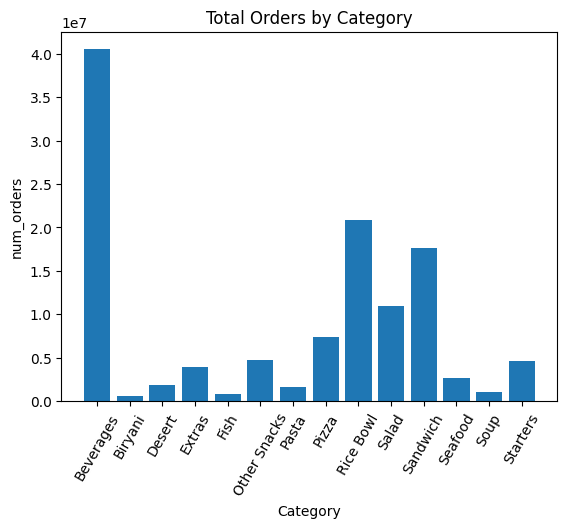

In [9]:
#bar graph
plt.bar(df_group.index, df_group)
#xticks

plt.xticks(rotation=60)
#x-axis labels
plt.xlabel('Category')

#y-axis labels
plt.ylabel('num_orders')

#plot title
plt.title('Total Orders by Category')


While analyzing the plot, we can see that Beverages were the most popular food item sold by the company. Wait, was it because they were sold with almost all the meals? Was Rice Bowl the most popular food item?

Let’s divide the total food item order by the number of unique meals it is present in.

In [10]:
df.groupby('category')['meal_id'].nunique()

category
Beverages       12
Biryani          3
Desert           3
Extras           3
Fish             3
Other Snacks     3
Pasta            3
Pizza            3
Rice Bowl        3
Salad            3
Sandwich         3
Seafood          3
Soup             3
Starters         3
Name: meal_id, dtype: int64

In [11]:
cat_orders['num_meals'] = df.groupby('category')['meal_id'].nunique()
cat_orders

,num_orders,num_meals
category,,
Beverages,40480525,12
Biryani,631848,3
Desert,1940754,3
Extras,3984979,3
Fish,871959,3
Other Snacks,4766293,3
Pasta,1637744,3
Pizza,7383720,3
Rice Bowl,20874063,3


**Ex: Lets' plot a new bar chart**

x = category

y = num_orders / num_meals

Text(0.5, 1.0, 'Total Orders by Category')

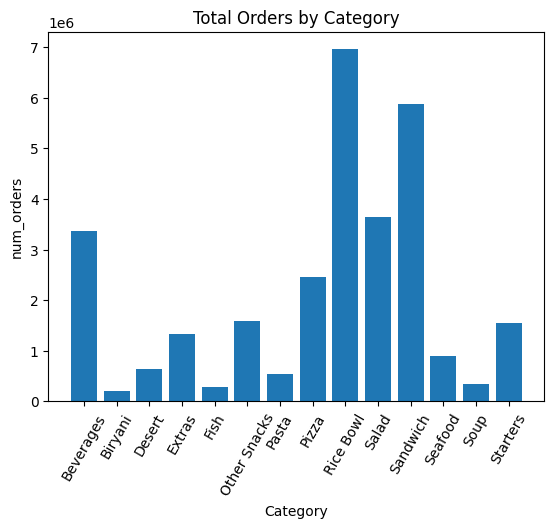

In [12]:
#bar graph
plt.bar(cat_orders.index, cat_orders.num_orders/cat_orders.num_meals)
#xticks

plt.xticks(rotation=60)
#x-axis labels
plt.xlabel('Category')

#y-axis labels
plt.ylabel('num_orders')

#plot title
plt.title('Total Orders by Category')


Yes, our hypothesis was correct! Rice Bowl was indeed the most popular food item sold by the company.

**Note:** Bar graphs should not be used for continuous values.

**2.Pie Chart using matplotlib**

Let us now see the ratio of orders from each cuisine.

A pie chart is suitable to show the proportional distribution of items within the same category.

In [13]:
# Create a DataFrame as below
# YOUR CODE HERE
#cat_orders["ratio"] = cat_orders.num_orders/cat_orders.num_orders.sum()
#cat_orders
sr = df.groupby('cuisine')['num_orders'].sum()
sr


cuisine
Continental    16914439
Indian         25792544
Italian        44172832
Thai           32677670
Name: num_orders, dtype: int64

([<matplotlib.patches.Wedge at 0x10e049760>,
 [Text(-1.064796761925068, 0.2760577037394363, 'Continental'),
  Text(-0.7105434514024083, -0.8397190028034102, 'Indian'),
  Text(0.9977458382166583, -0.4631449474207163, 'Italian'),
  Text(-0.015398752373676718, 1.0998922121850552, 'Thai')],
 [Text(-0.5807982337773098, 0.15057692931241975, '14.1%'),
  Text(-0.3875691553104045, -0.45802854698367823, '21.6%'),
  Text(0.5442250026636317, -0.25262451677493614, '36.9%'),
  Text(-0.008399319476550936, 0.5999412066463936, '27.3%')])

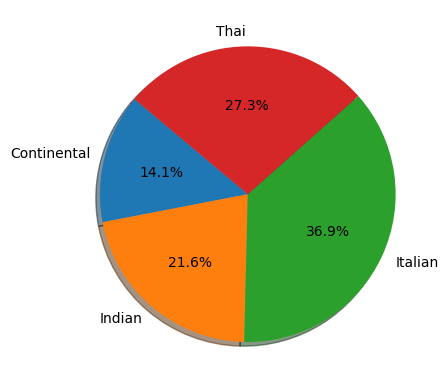

In [14]:
#pie plot
# Data to plot
labels = sr.index
sizes = sr.values

plt.pie(sizes, labels=labels, autopct='%1.1f%%', shadow=True, startangle=140)

**3.Box Plot using matplotlib**

Since we are discussing cuisine, let’s check out which one is the most expensive cuisine! For this, using a Box Plot.

**What are boxplots?**

A boxplot is a graphical and standardised way to display the distribution of data based on five key numbers:

1. The “minimum”,
2. 1st Quartile (25th percentile),
3. median (2nd Quartile./ 50th Percentile),
4. the 3rd Quartile (75th percentile), and
5. the “maximum”.

The minimum and maximum values are defined as Q1–1.5 * IQR and Q3 + 1.5 * IQR respectively. Any points that fall outside of these limits are referred to as outliers.

![boxplot](https://miro.medium.com/max/1400/1*oakP4vxTLwuqE8ce0fFQRA.png)

Boxplots can be used to:

- Identify outliers or anomalous data points
- To determine if our data is skewed
- To understand the spread/range of the data

[Ref: Creating Boxplots Using Matplotlib in Python](https://towardsdatascience.com/creating-boxplots-of-well-log-data-using-matplotlib-in-python-34c3816e73f4)

In [15]:
cuisines = df['cuisine'].unique()
cuisines

array(['Thai', 'Indian', 'Italian', 'Continental'], dtype=object)

**Ex: Create boxplots for each cuisine's base_price**

In [16]:
# YOUR CODE HERE
# plotting boxplot


Continental cuisine was the most expensive cuisine served by the company! Even its median price is higher than the maximum price of all the cuisines.

Box plot does not show the distribution of data points within each group.

**4.Histogram using matplotlib**

On the topic of prices, did we forget to inspect the base price and checkout price? Don’t worry, we will do that using a histogram.

A histogram shows the distribution of numeric data through a continuous interval by segmenting data into different bins. Useful for inspecting skewness in the data.

Since base_price is a continuous variable, we will inspect its range in different distinct orders using a histogram. We can do this using plt.hist().

But the confusing part is what should be the number of bins? By default, it is 10. However, there is no correct answer and you can vary it according to your dataset to best visualize it.

**Ex: Create a histogram of base_price**

In [17]:
#plotting histogram

#x and y-axis labels

#plot title


**5.Line Plot and Subplots using matplotlib**

A line plot is useful for visualizing the trend in a numerical value over a continuous time interval.

How are the weekly and monthly sales of the company varying? This is a critical business question that makes or breaks the marketing strategy.

Before exploring that, create two lists for storing the week-wise and month-wise revenue of the company:

In [18]:
df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine
0,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai
1,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai
2,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai
3,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian
4,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian


In [19]:
df.shape

(456548, 15)

In [20]:
df['revenue'] = df['checkout_price'] * df['num_orders']

In [21]:
from datetime import datetime
from dateutil.relativedelta import relativedelta

df['date'] = df['week'].apply(lambda x: datetime(2015, 1, 1) + relativedelta(weeks=x))

In [22]:
df[['date', 'week']].head()

,date,week
0,2015-01-08,1
1,2015-01-08,1
2,2015-01-08,1
3,2015-01-08,1
4,2015-01-08,1


In [23]:
df.set_index('date', inplace=True)

In [24]:
week_revenue = df['revenue'].resample('W').sum()
week_revenue

date
2015-01-11    2.185165e+08
2015-01-18    1.999142e+08
2015-01-25    1.780359e+08
2015-02-01    1.961360e+08
2015-02-08    2.596449e+08
                  ...     
2017-09-17    2.402112e+08
2017-09-24    2.236455e+08
2017-10-01    2.248748e+08
2017-10-08    2.297504e+08
2017-10-15    1.918333e+08
Freq: W-SUN, Name: revenue, Length: 145, dtype: float64

In [25]:
month_revenue = df['revenue'].resample('M').sum()
len(month_revenue)

/var/folders/4q/pnl_zvg11jj26x9_3_8wm6nm0000gn/T/ipykernel_64607/392964563.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_revenue = df['revenue'].resample('M').sum()


34

Compare the revenue of the company in every week as well as in every month using two line-plots drawn side by side. For this, using the `plt.subplots()` function.

Matplotlib subplots makes it easy to view and compare different plots in the same figure.

To understand how this function works, you need to know what Figure, Axes, and Axis are in a matplotlib plot.

Figure is the outermost container for the Matplotlib plot(s). There can a single or multiple plots, called Axes, within a Figure. Each of these Axes contains the x and y-axis known as the Axis.

The plt.subplots() figure returns the figure and axes. You can provide as an input to the function how you want to display the axes within the figure. These will be adjusted using the nrows and ncols parameters. You can even adjust the size of the figure using the figsize parameter.

Axes are returned as a list. To plot for specific axes, you can access them as a list object. The rest of the plotting is done the same way as simple plots:

In [26]:
#subplots returns a Figure and an Axes object


#manipulating the first Axes


#manipulating the second Axes


**6.Scatter Plot using matplotlib**

Finally, try to analyze whether the center type had any effect on the number of orders from different center types. I will do this by comparing a scatter plot, a boxplot and a bar graph in the same figure.

We have already seen the use of boxplots and bar graphs, but scatter plots have their own advantages.

Scatter plots are useful for showing the relationship between two variables. Any correlation between variables or outliers in the data can be easily spotted using scatter plots.

In [27]:
df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,city_code,region_code,center_type,op_area,category,cuisine,revenue
date,,,,,,,,,,,,,,,,
2015-01-08,1379560,1,55,1885,136.83,152.29,0,0,177,647,56,TYPE_C,2.0,Beverages,Thai,24218.91
2015-01-08,1466964,1,55,1993,136.83,135.83,0,0,270,647,56,TYPE_C,2.0,Beverages,Thai,36944.10
2015-01-08,1346989,1,55,2539,134.86,135.86,0,0,189,647,56,TYPE_C,2.0,Beverages,Thai,25488.54
2015-01-08,1338232,1,55,2139,339.50,437.53,0,0,54,647,56,TYPE_C,2.0,Beverages,Indian,18333.00
2015-01-08,1448490,1,55,2631,243.50,242.50,0,0,40,647,56,TYPE_C,2.0,Beverages,Indian,9740.00


In [28]:
df['op_area'].unique()

array([2. , 3.6, 3.7, 5.3, 3.8, 6.7, 5.6, 3.9, 3.4, 5. , 2.8, 2.4, 4.8,
       4. , 4.6, 4.4, 4.5, 4.1, 0.9, 4.2, 2.9, 2.7, 4.7, 3.2, 3. , 7. ,
       1.9, 3.5, 6.3, 5.1])

In [29]:
op_area_orders = df.groupby('op_area')['num_orders'].sum()
op_area_orders

op_area
0.9      425160
1.9      497338
2.0     1521501
2.4      637527
2.7     3058120
2.8     4656558
2.9      898613
3.0     2062748
3.2     1218319
3.4     3478065
3.5     1812167
3.6     4596156
3.7     2797300
3.8     7977964
3.9    10738365
4.0    11780398
4.1     5202521
4.2     3116118
4.4     8367833
4.5     8043504
4.6     1833427
4.7     1739081
4.8     5237062
5.0     1906535
5.1     5641494
5.3     1628964
5.6     3125835
6.3     3381018
6.7     4296545
7.0     7881249
Name: num_orders, dtype: int64

**Ex: Create a figure with 3 axes**

- The first axes is a scatter plots showing relation between op area and number of orders
- The second axes is a boxplot showing relation between center type and op area
- The last axes is a bar chart showing relation between center type and num of orders

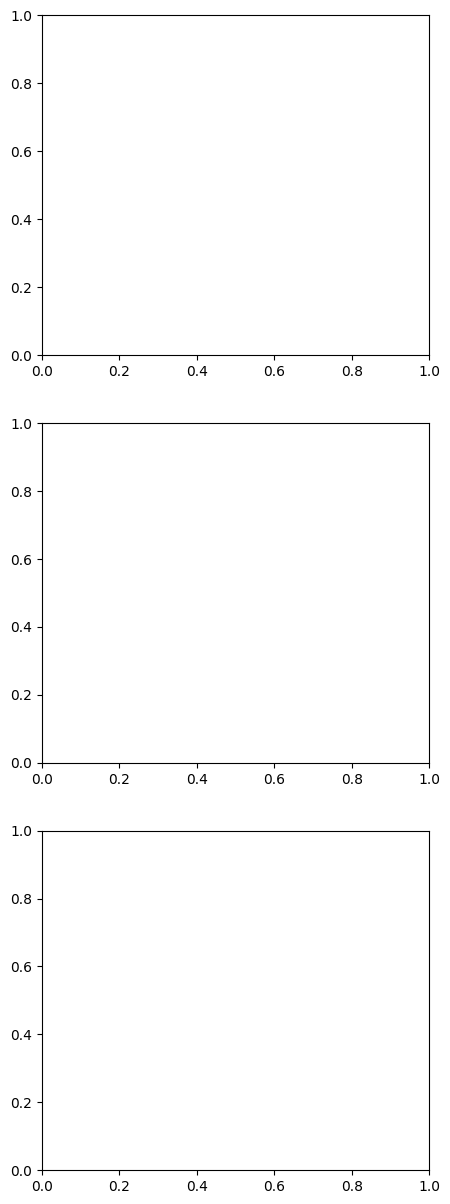

In [30]:
#subplots
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(5, 15))

#scatter plots - relation between op area and number of orders


#boxplot - relation between center type and op area


#bar graph - relation between center type and num of orders


The scatter plot makes it instantly visible that the optimum operation area of a center is 4 km sq. The boxplot shows that the TYPE_A center type had the most number of optimum size centers because of a compact box with a median around 4 km sq. Because of this, they had more orders placed by customers than any other center type.

# **Seaborn Exercises**

Time to practice your new seaborn skills! Try to create the plots below (don't worry about color schemes, just the plot itself.)

### **The Data**
We will be working with a famous titanic data set for these exercises. Later on in the Python for Machine Learning section of the course, we will revisit this data and focus on the visualization of the data with seaborn:

In [31]:
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [32]:
sns.set_style('whitegrid')

In [33]:
titanic = sns.load_dataset('titanic')

In [34]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


**Exercises**

**1.Assign `fare` and `age` to create a scatterplot with marginal histograms**

In [35]:
# YOUR CODE HERE


**2.Assign `fare` to create histogram** *(bins = 30)*

In [36]:
# YOUR CODE HERE


**3.Assign `class` and `age` to create boxplot**

In [37]:
# YOUR CODE HERE


**4.Assign `class` and `age` to create swarmplot**

In [38]:
# YOUR CODE HERE


**5.Assign `sex` to create bar chart**

In [39]:
# YOUR CODE HERE


**6.Plot heatmap correlation between variable in Titanic dataset**

In [40]:
titanic_numeric = titanic.select_dtypes(include=['number'])
titanic_numeric.corr()

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [41]:
# YOUR CODE HERE
# https://seaborn.pydata.org/generated/seaborn.heatmap.html


**7.Assign `sex` (male, female) to create `age` histogram**

In [42]:
# YOUR CODE HERE


## **Great Job!**